# 🔍 Chapter 06 — Model Explainability & SHAP Analysis

## 📖 Objective
Explain how the tuned Random Forest model makes predictions by analyzing feature importance and SHAP values, and connect these findings to real-world air quality dynamics.

### 🧠 Step 01 — Notebook Metadata & Explainability Overview

In this chapter, we focus on understanding **why** the optimized Random Forest model makes its predictions.  
Model performance alone is not sufficient for real-world decision-making — especially in environmental analytics, where policies and interventions rely on clear and transparent reasoning.

Model explainability helps us answer:

- Which features drive AQI predictions the most?  
- How does each environmental factor influence the model output?  
- Are the relationships linear, nonlinear, or dependent on interactions?  
- Can we justify the model behavior in a way that aligns with real environmental mechanisms?

In this step, we define the purpose, scope, and structure of Chapter 06.  
The following steps will walk through global feature importance, SHAP explainability, visual diagnostics, and interpretation of environmental insights.

### 📦 Step 02 — Load Final Random Forest Model

In this step, we load the final Random Forest model trained in Chapter 05.  
This model already contains the optimized hyperparameters, so there is no need for `best_estimator_`.

Once loaded, this model will be used for:
- Feature importance analysis  
- SHAP explainability  
- Visual interpretation of environmental factor impacts  

In [ ]:
import joblib
from src.config import MODEL_DIR
from src.utils.emoji_log import success, info

In [2]:
MODEL_PATH = MODEL_DIR / "rf_final_model_20251115_1215.pkl"
rf_model = joblib.load(MODEL_PATH)
success("Final model loaded successfully.")
rf_model

✅ Final model loaded successfully.


,n_estimators,120
,criterion,'squared_error'
,max_depth,20
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 🔍 Step 03 — Global Feature Importance Analysis

In this step, we compute the global feature importance of the Random Forest model.  
Feature importance measures how much each variable contributes to reducing error across all decision trees.

This provides a high-level overview of **which environmental factors are most influential** in predicting air quality (AQI or PM2.5).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.modeling.train_baseline import (
    split_train_test,
    load_cleaned_data,
    build_features,
)
from src.features.feature_engineering import (
    clip_pollutants,
    add_rolling_features,
    handle_outliers_iqr,
    log_transform_features,
    scale_features,
)

In [4]:
# === 1. Data Preparation ===
df = load_cleaned_data("Taiwan")

# === 2. Feature Engineering Pipeline ===
df_clip = clip_pollutants(df.copy())
df_rolling = add_rolling_features(df_clip)
df_iqr = handle_outliers_iqr(df_rolling)
df_log = log_transform_features(df_iqr)

# === 3. Feature construction ===
X, y = build_features(df_log)

# === 4. Scaling (same method as model training) ===
X_scaled = scale_features(X, save_=False)

# === 5. Train-test split ===
data_split = split_train_test(X_scaled, y)

X_train = data_split["X_train"]
X_test = data_split["X_test"]
y_train = data_split["y_train"]
y_test = data_split["y_test"]

info(f"X_train shape: {X_train.shape}")

📂 Loading CSV: C:\Users\dinni\OneDrive\桌面\air_pollution\data\processed\Taiwan.csv
✅ Read CSV successfully! Shape: (5823862, 25)
✅ The pollutants limit has been set.
⚠️ Skipping nox due to NO + NO2 already exist.
✅ Rolling features added.
✅ IQR has been set.
✅ Pollutants skewes has been smoothed.
💬 Features shape: (5823862, 32), Target shape: (5823862,)
✅ Numerical features have been standardized. (32 columns scaled)
✅ Data successfully split! Train: (4659089, 32), Test: (1164773, 32)
💬 X_train shape: (4659089, 32)


In [6]:
feature_names = X_train.columns

importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

fi_df = fi_df.sort_values("importance")

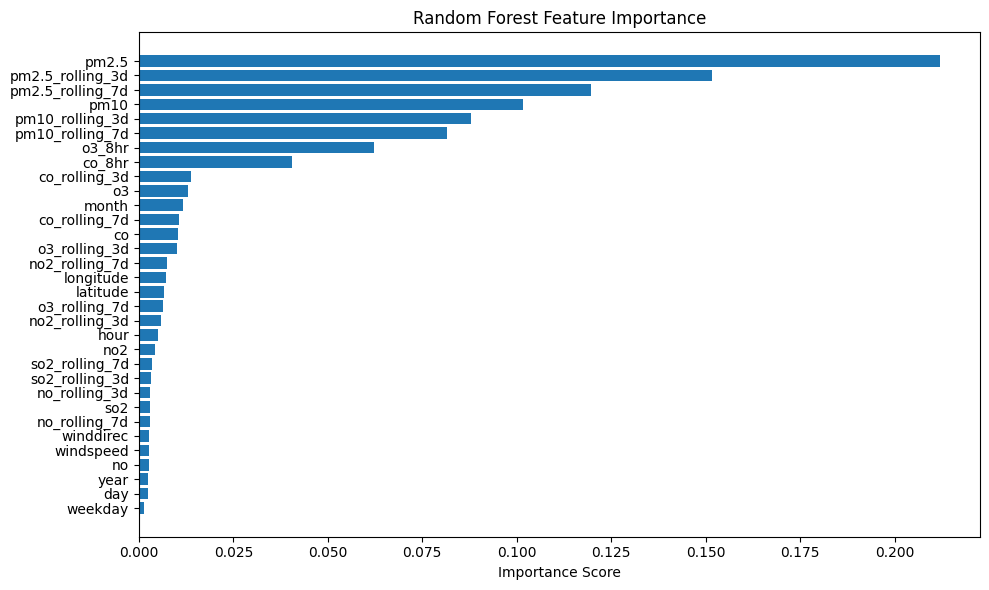

In [7]:
plt.figure(figsize=(10,6))
plt.barh(fi_df["feature"], fi_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

#### 📝 Step 03 Summary — What the Feature Importance Tells Us

The feature importance analysis shows that **PM2.5 and its rolling-window features** (3-day and 7-day averages) are by far the strongest predictors in the model.  
This indicates that air quality is heavily influenced by short-term particulate trends.

Other pollutants such as PM10, O₃ (8-hr), and CO also contribute, but their impact is noticeably smaller compared to PM2.5-related features.

Temporal features (month, hour, weekday) and meteorological features (wind speed, wind direction) play a minor role, which aligns with expectations—they influence air quality indirectly rather than being direct pollutant measurements.

Overall, these results provide a clear global picture of the model’s behavior and set the stage for the next step: **SHAP analysis**,  
which will explain *how* each feature affects individual predictions.

### 🧮 Step 04 — Initialize SHAP Explainer  
Setting up the SHAP framework to interpret how each feature contributes to the model’s predictions.  

---

In this step, we create a SHAP Explainer for the Random Forest model.  
SHAP (SHapley Additive exPlanations) provides a unified framework to measure  
**how much each feature pushes a prediction higher or lower**.

For tree-based models like Random Forest, the most efficient choice is:

- `shap.TreeExplainer` — optimized for tree ensembles  
- Fast computation  
- Accurate per-feature attribution  
- Supports SHAP interaction values (optional)

We will apply TreeExplainer to the final model and compute SHAP values on the test set.

In [8]:
import shap

In [11]:
X_test_sample = X_test.sample(2000, random_state=42)

### 📊 Step 05 — SHAP Summary Plot (Global Effects)
Generate SHAP summary plots to analyze global feature importance, effect direction, and impact distribution across all observations.

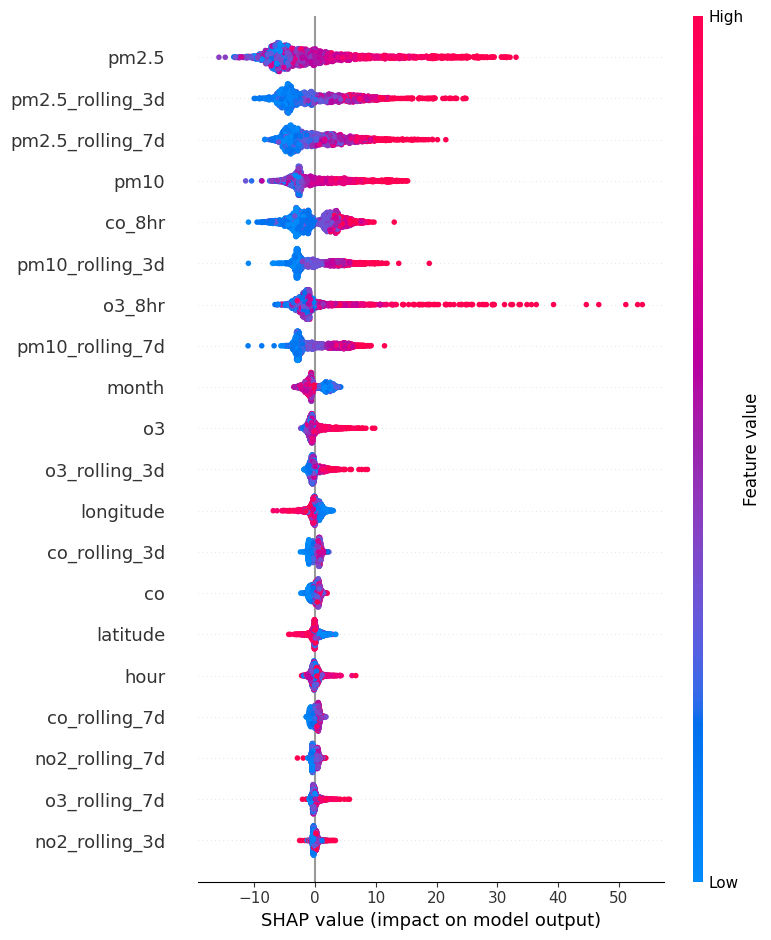

In [12]:
explainer = shap.TreeExplainer(rf_model, feature_perturbation="tree_path_dependent")

shap_values = explainer.shap_values(X_test_sample, approximate=True)

shap.summary_plot(shap_values, X_test_sample)

#### 📝 Step 05 Summary — Understanding the SHAP Summary Plot  

The SHAP summary plot provides a global explanation of how each feature
influences the model’s AQI predictions.  
Each point represents one sample, showing how much a specific feature increases or decreases the predicted AQI for that sample.

**Key observations：**

1. **PM2.5 and its rolling averages are the strongest drivers of AQI.**  
   High PM2.5 values consistently push predictions upward (red points on the right).  

2. **PM10 and CO/O₃ features show secondary but meaningful influence.**  
   They can increase AQI, especially when their values are high.  

3. **The wide SHAP range for O₃ (8hr) indicates occasional strong impact.**  
   In most samples its effect is mild, but in certain high-O₃ cases, it can increase AQI by 40–50 points. 

4. **Temporal and location features (month, hour, latitude/longitude) have weaker influence.**  

Overall, the summary plot confirms that **particle pollutants (PM2.5/PM10)** dominate AQI prediction, while **gaseous pollutants (O₃, CO)** exert strong influence only under specific conditions.

### 🔍 Step 06 — SHAP Dependence Plots  
**Understanding feature interactions & nonlinear effects**  

SHAP dependence plots reveal how each feature affects AQI predictions across different value ranges, and how this effect interacts with other features.

---

#### ⭐ Recommended features to analyze
Based on SHAP importance, the following five features contain the most informative nonlinear patterns and interactions:

1. **pm2.5**  
2. **pm2.5_rolling_3d**  
3. **pm10_rolling_3d**  
4. **o3_8hr**  
5. **co_8hr**

These features capture both direct pollution impact and short-term temporal trends.

---

#### 📌 What to look for in dependence plots?  

Each plot shows:

- **X-axis** → the raw feature value  
- **Y-axis** → SHAP value (impact on AQI)
- **Color** → another interacting feature

You should identify:

- Nonlinear spikes
- Threshold effects
- Saturation or plateaus
- Interaction between features

Dependence plots reveal behavior that feature importance alone cannot show.

---

After generating the plots, summarize how each feature influences AQI  
(e.g., increasing trends, thresholds, interactions).

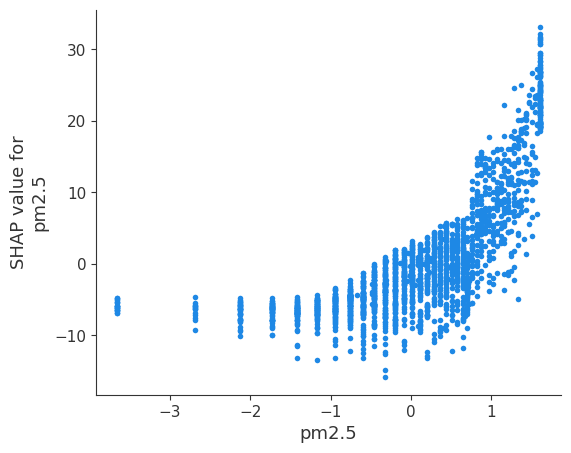

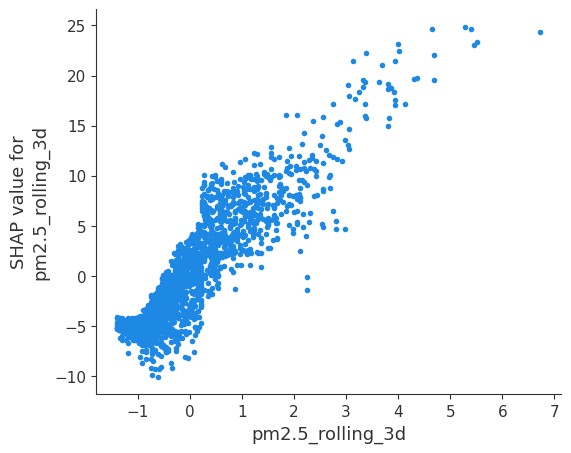

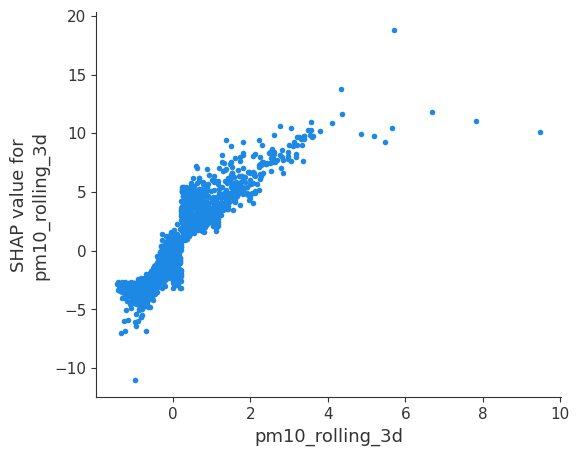

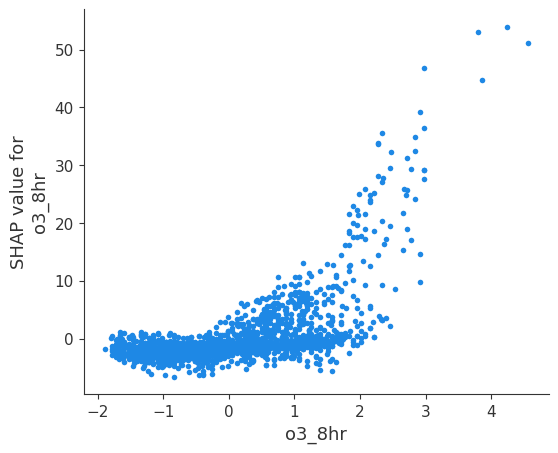

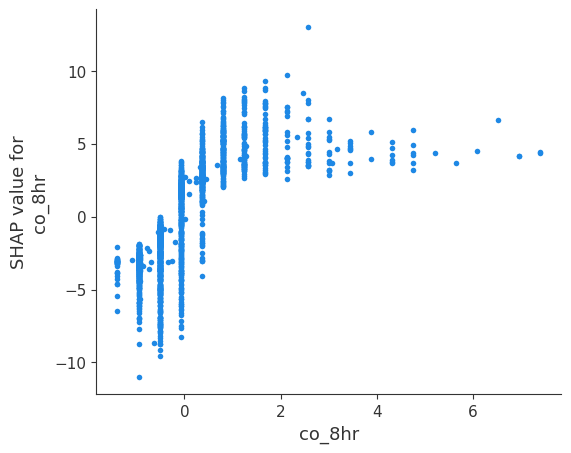

In [15]:
if isinstance(shap_values, list):
    shap_array = shap_values[0]
else:
    shap_array = shap_values

feature_to_plot = [
    "pm2.5",
    "pm2.5_rolling_3d",
    "pm10_rolling_3d",
    "o3_8hr",
    "co_8hr",
]

for feature in feature_to_plot:
    shap.dependence_plot(
        feature, shap_array, X_test_sample, interaction_index=None, show=True
    )

### 📝 Step 07 — Interpretation of SHAP Dependence Plots  
**Nonlinear patterns and feature behavior**  

The dependence plots reveal clear nonlinear relationships between pollutants and the predicted AQI. 

Key insights:

#### 1. PM2.5 shows a strong nonlinear “acceleration effect.”  
Low values cause minimal impact, but high PM2.5 produces a rapid rise in SHAP value (up to +20〜+30), indicating sharp deterioration in air quality.

#### 2. PM2.5 (3-day rolling) contributes steadily and accumulatively.  
It reflects short-term pollution buildup and increases AQI influence smoothly.

#### 3. PM10 rolling averages also increase AQI but less aggressively.  
They act as secondary particle pollutants.

#### 4. O₃ (8hr) shows a long-tail pattern.  
Most values have mild effect, but high-O₃ events produce extreme SHAP values (+40〜+55).

#### 5. CO (8hr) exhibits a saturation effect.  
Moderate CO increases AQI, but very high CO yields diminishing influence.

---

Overall, the model shows that **particle pollutants (PM2.5/PM10) dominate AQI prediction**, while **gaseous pollutants (O₃, CO) have strong but episodic influences** depending on concentration levels.